In [1]:
from google.colab import files
uploaded = files.upload()   # upload the ZIP


Saving Project 2-20251111T025938Z-1-001.zip to Project 2-20251111T025938Z-1-001.zip


In [2]:
import os
os.listdir()


['.config', 'Project 2-20251111T025938Z-1-001.zip', 'sample_data']

In [3]:
!unzip "Project 2-20251111T025938Z-1-001.zip" -d project2


Archive:  Project 2-20251111T025938Z-1-001.zip
  inflating: project2/Project 2/dataset.py  
  inflating: project2/Project 2/data.csv  
  inflating: project2/Project 2/requirements.txt  
  inflating: project2/Project 2/model.py  
  inflating: project2/Project 2/main.py  
  inflating: project2/Project 2/README.md  
  inflating: project2/Project 2/utils.py  
  inflating: project2/Project 2/sub_val/DX103881.jpg  
  inflating: project2/Project 2/sub_val/DX301633.jpg  
  inflating: project2/Project 2/inference.py  
  inflating: project2/Project 2/sub_val/DX48365.jpg  
  inflating: project2/Project 2/sub_val/DX147030.jpg  
  inflating: project2/Project 2/sub_val/DX42449.jpg  
  inflating: project2/Project 2/sub_val/DX409235.jpg  
  inflating: project2/Project 2/sub_val/DX377808.jpg  
  inflating: project2/Project 2/sub_val/DX94963.jpg  
  inflating: project2/Project 2/sub_val/DX368522.jpg  
  inflating: project2/Project 2/sub_val/DX211591.jpg  
  inflating: project2/Project 2/sub_val/DX263464

In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install numpy pandas scikit-learn matplotlib pillow tqdm albumentations opencv-python timm


Looking in indexes: https://download.pytorch.org/whl/cu121


# Verify the Dataset and CSV

In [5]:
%cd /content/project2/Project 2
!ls


/content/project2/Project 2
data.csv    inference.py  model.py   requirements.txt  sub_val
dataset.py  main.py	  README.md  sub_train	       utils.py


In [6]:
import os, pandas as pd

print("Files:", os.listdir('.'))
print("Training images:", len(os.listdir('sub_train')))
print("Validation images:", len(os.listdir('sub_val')))

df = pd.read_csv('data.csv')
df.head()


Files: ['dataset.py', 'model.py', 'main.py', 'sub_val', 'requirements.txt', 'inference.py', 'utils.py', 'README.md', 'data.csv', 'sub_train']
Training images: 500
Validation images: 100


,exam_number,score_avg,split,image_filename
0,129099,5.0,train,DX129099.jpg
1,38829,35.5,train,DX38829.jpg
2,331745,5.5,train,DX331745.jpg
3,340766,31.5,train,DX340766.jpg
4,368607,40.0,train,DX368607.jpg


# Train the Baseline Model

In [7]:
import torch.optim as optim

# ⚙️ Patch ReduceLROnPlateau to ignore unsupported 'verbose' arg
orig_init = optim.lr_scheduler.ReduceLROnPlateau.__init__

def safe_init(self, optimizer, *args, **kwargs):
    kwargs.pop("verbose", None)  # removes verbose if present
    orig_init(self, optimizer, *args, **kwargs)

optim.lr_scheduler.ReduceLROnPlateau.__init__ = safe_init
print("✅ Patched ReduceLROnPlateau: 'verbose' argument will be ignored safely.")


✅ Patched ReduceLROnPlateau: 'verbose' argument will be ignored safely.


In [8]:
!sed -i 's/verbose=True//g' "main.py"


In [9]:
!sed -i "s/torch.load(filepath, map_location=device)/torch.load(filepath, map_location=device, weights_only=False)/g" '/content/project2/Project 2/utils.py'


In [ ]:
!python main.py --model simple_cnn --epochs 50 --batch_size 32 --lr 0.001 --num_workers 2


Using device: cuda

Creating data loaders...
Loaded 500 samples for train set
Score range: [0.00, 260.50]
Loaded 100 samples for val set
Score range: [0.00, 207.00]

Creating model...
Model: simple_cnn
Total parameters: 26,080,513
Trainable parameters: 26,080,513

Starting training...

Epoch 1/50
------------------------------------------------------------
Epoch [1] Batch [10/16] Loss: 2205.1436 (Avg: 4770.7632)

Epoch 1 Results:
Train Loss: 3969.4150
Val Loss: 2120.0104
Val MAE: 32.7883
Val RMSE: 46.0436
Val R²: -0.0383
Learning Rate: 0.001000
Checkpoint saved to checkpoints/simple_cnn_20251127_190449/best_model.pth
✓ Best model saved (Val Loss: 2120.0104)
Checkpoint saved to checkpoints/simple_cnn_20251127_190449/latest_model.pth

Epoch 2/50
------------------------------------------------------------
Epoch [2] Batch [10/16] Loss: 1073.6050 (Avg: 2342.6371)

Epoch 2 Results:
Train Loss: 2308.3522
Val Loss: 2027.5543
Val MAE: 33.4163
Val RMSE: 45.0284
Val R²: 0.0070
Learning Rate: 0.0

In [ ]:
!ls "/content/project2/Project 2/sub_val" | head -10


DX103881.jpg
DX118997.jpg
DX120946.jpg
DX121258.jpg
DX122817.jpg
DX124826.jpg
DX128733.jpg
DX135960.jpg
DX146382.jpg
DX147030.jpg


In [ ]:
import os

for root, dirs, files in os.walk("/content/project2"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))


/content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth
/content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/latest_model.pth


In [ ]:
!python "/content/project2/Project 2/inference.py" \
  --checkpoint "/content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth" \
  --image_path "/content/project2/Project 2/sub_val/DX128733.jpg" \
  --model simple_cnn


Using device: cuda

Creating model...
Loading checkpoint: /content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth
Checkpoint loaded from /content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth

Predicting on image: /content/project2/Project 2/sub_val/DX128733.jpg
Predicted score: 38.19
Results saved to: predictions.csv


In [ ]:
!python "/content/project2/Project 2/inference.py" \
  --checkpoint "/content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth" \
  --image_dir "/content/project2/Project 2/sub_val" \
  --model simple_cnn \
  --output "results.csv"


Using device: cuda

Creating model...
Loading checkpoint: /content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth
Checkpoint loaded from /content/project2/Project 2/checkpoints/simple_cnn_20251127_190449/best_model.pth

Batch prediction on images in directory: /content/project2/Project 2/sub_val
Found 100 images
Processed 32/100 images
Processed 64/100 images
Processed 96/100 images
Processed 100/100 images

Results saved to: results.csv

Prediction Statistics:
Min: 8.14
Max: 149.80
Mean: 47.88
Std: 29.94


# Student Model

In [10]:
%%writefile "/content/project2/Project 2/model.py"
"""
Model Module for Medical Image Regression Task
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ============================================================
# SIMPLE CNN BASELINE
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, num_channels=3):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(num_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x.squeeze(1)

# ============================================================
# CBAM ATTENTION (Correct Version)
# ============================================================

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

        # Spatial Attention
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()

        avg = self.avg_pool(x).view(b, c)
        maxv = self.max_pool(x).view(b, c)

        ca = self.sigmoid(self.mlp(avg) + self.mlp(maxv)).view(b, c, 1, 1)
        x = x * ca

        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        sa = self.spatial(torch.cat([avg_out, max_out], dim=1))

        return x * sa

# ============================================================
# STUDENT MODEL: ResNet34 + CBAM + Feature Fusion
# ============================================================

class StudentModel(nn.Module):
    def __init__(self, num_channels=3, pretrained=True):
        super(StudentModel, self).__init__()

        base = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT if pretrained else None
        )

        self.stem = nn.Sequential(
            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool
        )

        self.layer1 = base.layer1  # 64
        self.layer2 = base.layer2  # 128
        self.layer3 = base.layer3  # 256
        self.layer4 = base.layer4  # 512

        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

        self.reduce3 = nn.Conv2d(256, 128, 1)
        self.reduce4 = nn.Conv2d(512, 128, 1)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Linear(128 * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x3 = self.layer3(x)
        x4 = self.layer4(x3)

        x3 = self.cbam3(x3)
        x4 = self.cbam4(x4)

        f3 = self.pool(self.reduce3(x3)).view(x.size(0), -1)
        f4 = self.pool(self.reduce4(x4)).view(x.size(0), -1)

        feat = torch.cat([f3, f4], dim=1)

        return self.regressor(feat).squeeze(1)

# ============================================================
# FACTORY
# ============================================================

def get_model(model_name='simple_cnn', **kwargs):
    if model_name == 'simple_cnn':
        return SimpleCNN(**kwargs)
    elif model_name == 'student':
        return StudentModel(**kwargs)
    else:
        raise ValueError(f"Unknown model: {model_name}")

# ============================================================

if __name__ == '__main__':
    model = StudentModel()
    x = torch.randn(4, 3, 224, 224)
    out = model(x)
    print("Output shape:", out.shape)
    print("Params:", sum(p.numel() for p in model.parameters()))


Overwriting /content/project2/Project 2/model.py


In [ ]:
!python "/content/project2/Project 2/main.py" \
  --model student


Using device: cuda

Creating data loaders...
Loaded 500 samples for train set
Score range: [0.00, 260.50]
Loaded 100 samples for val set
Score range: [0.00, 207.00]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(

Creating model...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 194MB/s]
Model: student
Total parameters: 21,508,023
Trainable parameters: 21,508,023

Starting training...

Epoch 1/50
------------------------------------------------------------
Epoch [1] Batch 

In [ ]:
!python "/content/project2/Project 2/inference.py" \
  --checkpoint "/content/project2/Project 2/checkpoints/student_20251127_191512/best_model.pth" \
  --image_path "/content/project2/Project 2/sub_val/DX128733.jpg" \
  --model student


Using device: cuda

Creating model...
Loading checkpoint: /content/project2/Project 2/checkpoints/student_20251127_191512/best_model.pth
Checkpoint loaded from /content/project2/Project 2/checkpoints/student_20251127_191512/best_model.pth

Predicting on image: /content/project2/Project 2/sub_val/DX128733.jpg
Predicted score: 47.20
Results saved to: predictions.csv


In [ ]:
!python "/content/project2/Project 2/inference.py" \
  --checkpoint "/content/project2/Project 2/checkpoints/student_20251127_191512/best_model.pth" \
  --image_dir "/content/project2/Project 2/sub_val" \
  --model student \
  --output "student_results.csv"


Using device: cuda

Creating model...
Loading checkpoint: /content/project2/Project 2/checkpoints/student_20251127_191512/best_model.pth
Checkpoint loaded from /content/project2/Project 2/checkpoints/student_20251127_191512/best_model.pth

Batch prediction on images in directory: /content/project2/Project 2/sub_val
Found 100 images
Processed 32/100 images
Processed 64/100 images
Processed 96/100 images
Processed 100/100 images

Results saved to: student_results.csv

Prediction Statistics:
Min: 6.03
Max: 165.00
Mean: 41.13
Std: 37.68


Using device: cuda
Loaded 100 samples for val set
Score range: [0.00, 207.00]

Loaded model: student
Checkpoint: checkpoints/student_20251127_191512/best_model.pth

Showing 6 random validation samples...



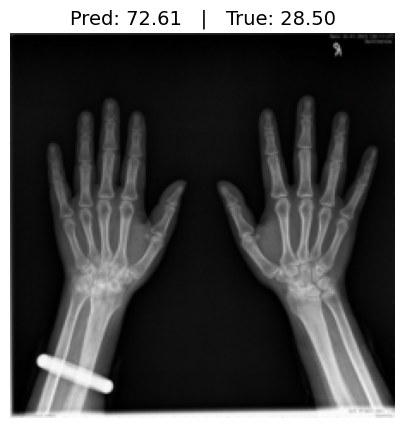

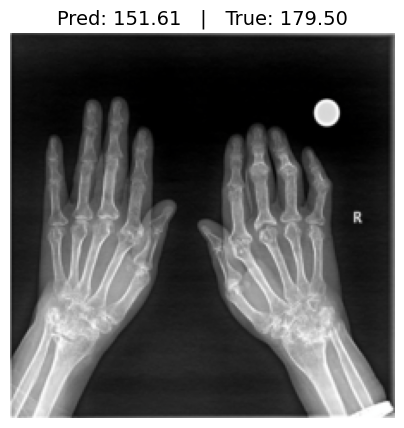

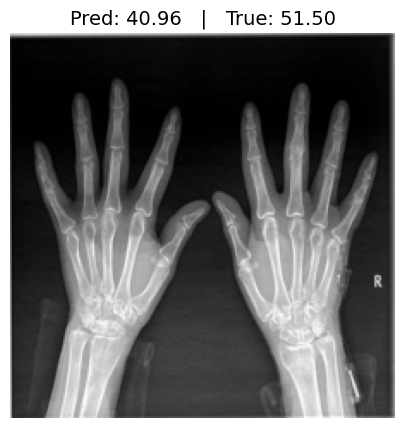

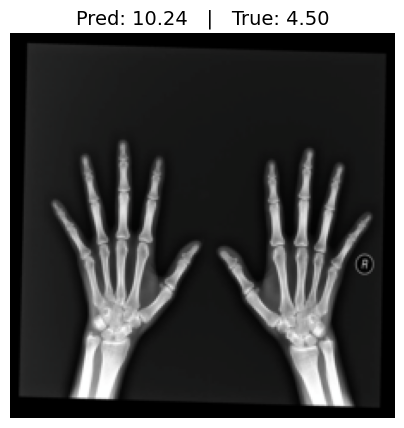

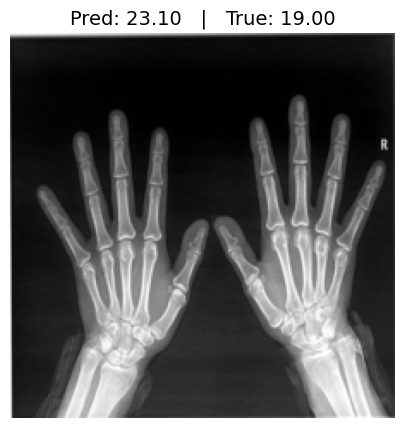

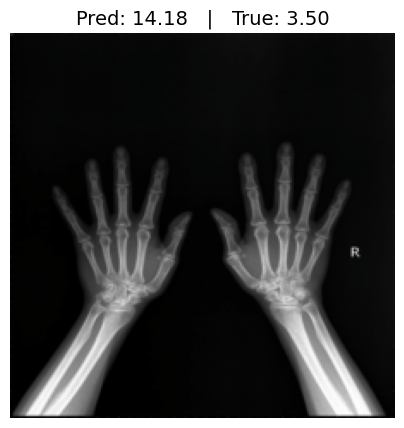

In [ ]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataset import MedicalImageDataset, get_transforms
from model import get_model
from torchvision import transforms

# -------------------------------------
# FIX for PyTorch 2.6 Safe Loading
# -------------------------------------
import numpy as np
import torch.serialization
torch.serialization.add_safe_globals([np._core.multiarray.scalar])

# -------------------------------------
# CONFIG
# -------------------------------------
CSV_FILE = "data.csv"
VAL_DIR = "sub_val"
CHECKPOINT = "checkpoints/student_20251127_191512/best_model.pth"
MODEL_NAME = "student"
IMAGE_SIZE = 224
NUM_IMAGES = 6   # how many random samples to show
# -------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------
# Load Dataset (Validation Only)
# -------------------------------------
val_dataset = MedicalImageDataset(
    csv_file=CSV_FILE,
    img_dir=VAL_DIR,
    split="val",
    transform=get_transforms(IMAGE_SIZE, is_train=False)
)

# -------------------------------------
# Load Model
# -------------------------------------
model = get_model(MODEL_NAME)
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("\nLoaded model:", MODEL_NAME)
print("Checkpoint:", CHECKPOINT)

# -------------------------------------
# Pick random samples
# -------------------------------------
indices = random.sample(range(len(val_dataset)), NUM_IMAGES)

print(f"\nShowing {NUM_IMAGES} random validation samples...\n")

for idx in indices:
    image, true_score, info = val_dataset[idx]

    # Save original image (before tensor norm)
    img_for_display = image.clone()
    img_for_display = img_for_display.cpu().permute(1,2,0).numpy()
    img_for_display = np.clip((img_for_display * np.array([0.229,0.224,0.225]) +
                               np.array([0.485,0.456,0.406])), 0, 1)

    # Model prediction
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(image).item()

    # -------------------------------------
    # Plot image + display prediction text
    # -------------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(img_for_display)
    plt.title(f"Pred: {pred:.2f}   |   True: {true_score:.2f}", fontsize=14)
    plt.axis("off")
    plt.show()


# Best Results

In [11]:
!python "/content/project2/Project 2/main.py" \
  --model student \
  --epochs 50 \
  --batch_size 16 \
  --lr 5e-4 \
  --optimizer adamw \
  --scheduler cosine \
  --weight_decay 1e-5


Using device: cuda

Creating data loaders...
Loaded 500 samples for train set
Score range: [0.00, 260.50]
Loaded 100 samples for val set
Score range: [0.00, 207.00]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(

Creating model...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 138MB/s]
Model: student
Total parameters: 21,508,023
Trainable parameters: 21,508,023

Starting training...

Epoch 1/50
------------------------------------------------------------
Epoch [1] Batch 

In [12]:
!python "/content/project2/Project 2/inference.py" \
  --checkpoint "/content/project2/Project 2/checkpoints/student_20251128_012630/best_model.pth" \
  --image_path "/content/project2/Project 2/sub_val/DX128733.jpg" \
  --model student


Using device: cuda

Creating model...
Loading checkpoint: /content/project2/Project 2/checkpoints/student_20251128_012630/best_model.pth
Checkpoint loaded from /content/project2/Project 2/checkpoints/student_20251128_012630/best_model.pth

Predicting on image: /content/project2/Project 2/sub_val/DX128733.jpg
Predicted score: 11.99
Results saved to: predictions.csv


In [14]:
!python "/content/project2/Project 2/inference.py" \
  --checkpoint "/content/project2/Project 2/checkpoints/student_20251128_012630/best_model.pth" \
  --image_dir "/content/project2/Project 2/sub_val" \
  --model student \
  --output "student_results.csv"


Using device: cuda

Creating model...
Loading checkpoint: /content/project2/Project 2/checkpoints/student_20251128_012630/best_model.pth
Checkpoint loaded from /content/project2/Project 2/checkpoints/student_20251128_012630/best_model.pth

Batch prediction on images in directory: /content/project2/Project 2/sub_val
Found 100 images
Processed 32/100 images
Processed 64/100 images
Processed 96/100 images
Processed 100/100 images

Results saved to: student_results.csv

Prediction Statistics:
Min: 6.81
Max: 171.63
Mean: 37.91
Std: 38.05


Using device: cuda
Loaded 100 samples for val set
Score range: [0.00, 207.00]

Loaded model: student
Checkpoint: checkpoints/student_20251128_012630/best_model.pth

Showing 1 random validation samples...



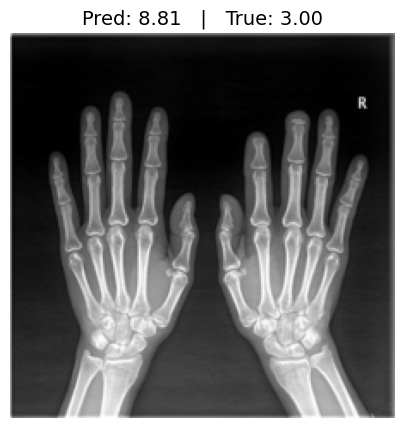

In [19]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataset import MedicalImageDataset, get_transforms
from model import get_model
from torchvision import transforms

# -------------------------------------
# FIX for PyTorch 2.6 Safe Loading
# -------------------------------------
import numpy as np
import torch.serialization
torch.serialization.add_safe_globals([np._core.multiarray.scalar])

# -------------------------------------
# CONFIG
# -------------------------------------
CSV_FILE = "data.csv"
VAL_DIR = "sub_val"
CHECKPOINT = "checkpoints/student_20251128_012630/best_model.pth"
MODEL_NAME = "student"
IMAGE_SIZE = 224
NUM_IMAGES = 1   # how many random samples to show
# -------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------
# Load Dataset (Validation Only)
# -------------------------------------
val_dataset = MedicalImageDataset(
    csv_file=CSV_FILE,
    img_dir=VAL_DIR,
    split="val",
    transform=get_transforms(IMAGE_SIZE, is_train=False)
)

# -------------------------------------
# Load Model
# -------------------------------------
model = get_model(MODEL_NAME)
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("\nLoaded model:", MODEL_NAME)
print("Checkpoint:", CHECKPOINT)

# -------------------------------------
# Pick random samples
# -------------------------------------
indices = random.sample(range(len(val_dataset)), NUM_IMAGES)

print(f"\nShowing {NUM_IMAGES} random validation samples...\n")

for idx in indices:
    image, true_score, info = val_dataset[idx]

    # Save original image (before tensor norm)
    img_for_display = image.clone()
    img_for_display = img_for_display.cpu().permute(1,2,0).numpy()
    img_for_display = np.clip((img_for_display * np.array([0.229,0.224,0.225]) +
                               np.array([0.485,0.456,0.406])), 0, 1)

    # Model prediction
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(image).item()

    # -------------------------------------
    # Plot image + display prediction text
    # -------------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(img_for_display)
    plt.title(f"Pred: {pred:.2f}   |   True: {true_score:.2f}", fontsize=14)
    plt.axis("off")
    plt.show()


In [23]:
!zip -r project2.zip /content/project2


  adding: content/project2/ (stored 0%)
  adding: content/project2/Project 2/ (stored 0%)
  adding: content/project2/Project 2/dataset.py (deflated 71%)
  adding: content/project2/Project 2/model.py (deflated 72%)
  adding: content/project2/Project 2/main.py (deflated 73%)
  adding: content/project2/Project 2/__pycache__/ (stored 0%)
  adding: content/project2/Project 2/__pycache__/utils.cpython-312.pyc (deflated 55%)
  adding: content/project2/Project 2/__pycache__/dataset.cpython-312.pyc (deflated 51%)
  adding: content/project2/Project 2/__pycache__/model.cpython-312.pyc (deflated 59%)
  adding: content/project2/Project 2/sub_val/ (stored 0%)
  adding: content/project2/Project 2/sub_val/DX376882.jpg (deflated 2%)
  adding: content/project2/Project 2/sub_val/DX399185.jpg (deflated 1%)
  adding: content/project2/Project 2/sub_val/DX121258.jpg (deflated 4%)
  adding: content/project2/Project 2/sub_val/DX409235.jpg (deflated 1%)
  adding: content/project2/Project 2/sub_val/DX329334.jpg 

In [24]:
from google.colab import files
files.download("project2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>